In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('german_credit_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [7]:
df.nunique()

Unnamed: 0          1000
Age                   53
Sex                    2
Job                    4
Housing                3
Saving accounts        4
Checking account       3
Credit amount        921
Duration              33
Purpose                8
Risk                   2
dtype: int64

In [8]:
df['Purpose'].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [9]:
df['Checking account'].value_counts()

Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64

In [10]:
df['Saving accounts'].value_counts()

Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [11]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')

<Axes: xlabel='Age', ylabel='Density'>

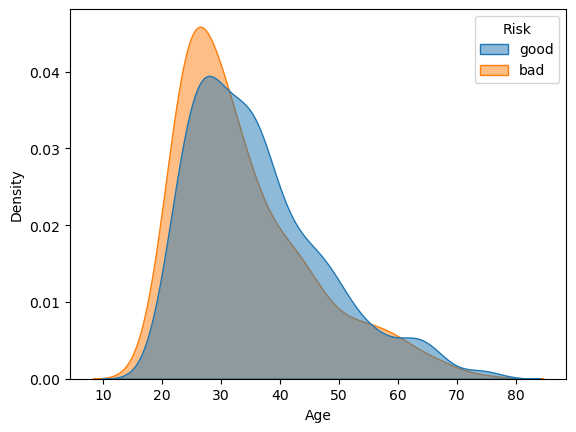

In [12]:
sns.kdeplot(data=df, x='Age', hue='Risk', fill=True, common_norm=False, alpha=0.5)

<Axes: xlabel='Sex', ylabel='count'>

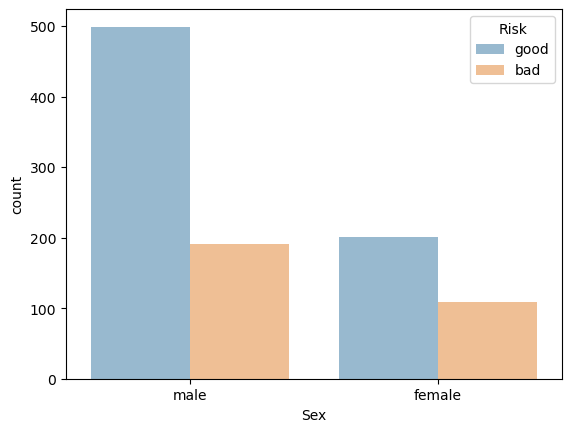

In [13]:
sns.countplot(data=df, x='Sex', hue='Risk', alpha=0.5)

<Axes: xlabel='Sex', ylabel='Age'>

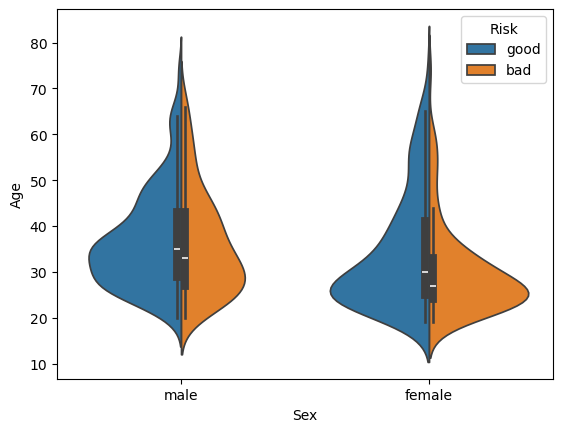

In [14]:
sns.violinplot(data=df, x='Sex', y='Age', hue='Risk', split=True)

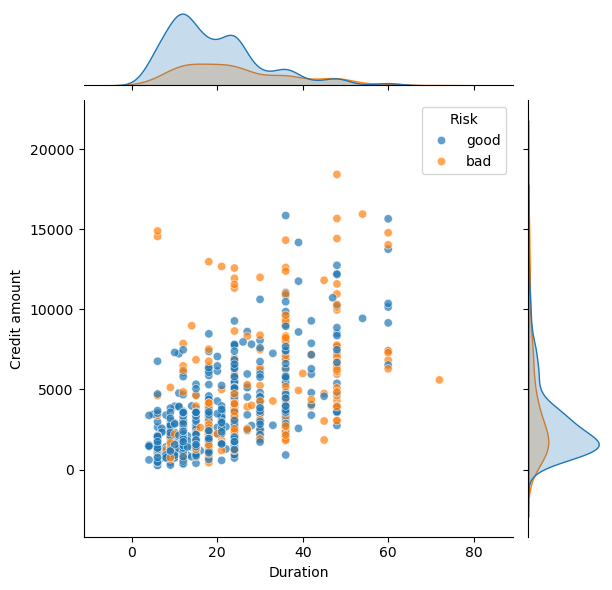

In [15]:
sns.jointplot(data=df, x='Duration', y='Credit amount', hue='Risk', alpha=0.7)

<Axes: xlabel='Purpose', ylabel='count'>

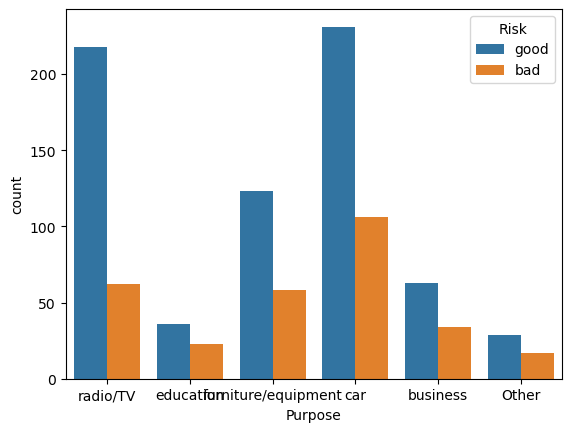

In [16]:
df['Purpose'] = df['Purpose'].replace(['repairs', 'domestic appliances', 'vacation/others'], 'Other')
sns.countplot(data=df,x='Purpose',hue='Risk')

<Axes: xlabel='Checking account', ylabel='count'>

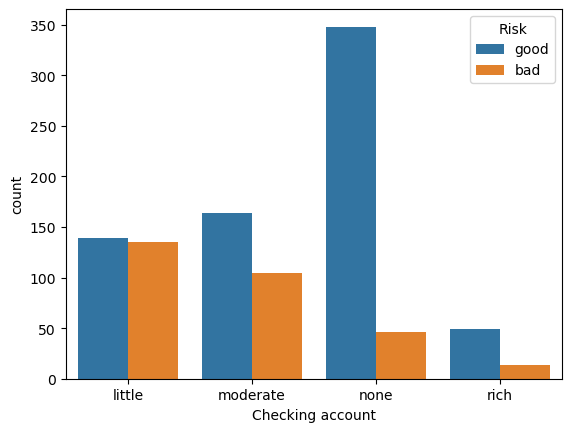

In [17]:
sns.countplot(data=df,x='Checking account',hue='Risk')

<Axes: xlabel='Saving accounts', ylabel='count'>

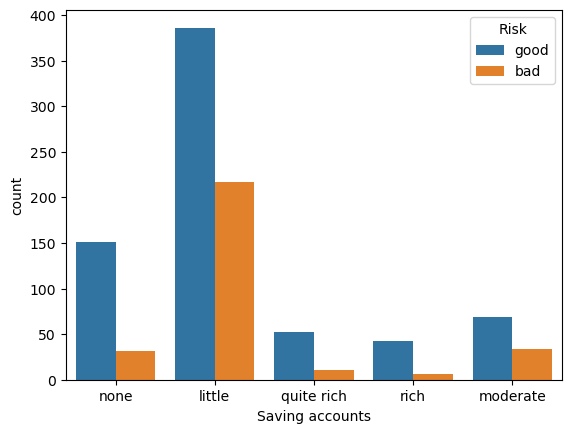

In [18]:
sns.countplot(data=df,x='Saving accounts',hue='Risk')

<Axes: xlabel='Housing', ylabel='Duration'>

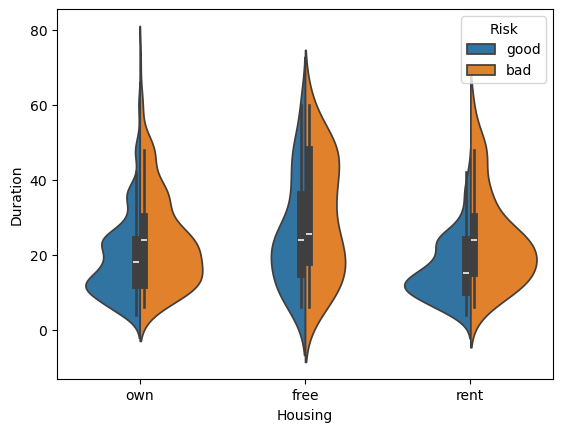

In [19]:
sns.violinplot(data=df, x='Housing', y='Duration', hue='Risk', split=True)

In [20]:
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [21]:
df=df.drop(columns=['Unnamed: 0'])

In [22]:
df['credit_per_month']=df['Credit amount']/df['Duration']
df['credit_age']=df['Credit amount']/df['Age']

<Axes: xlabel='credit_per_month', ylabel='Density'>

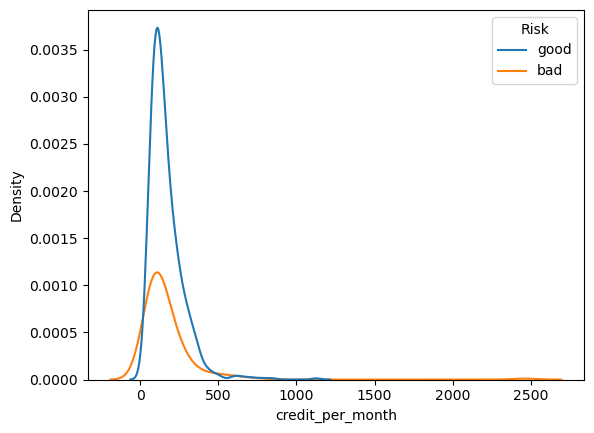

In [23]:
sns.kdeplot(data=df,x='credit_per_month',hue='Risk')

<Axes: xlabel='credit_age', ylabel='Density'>

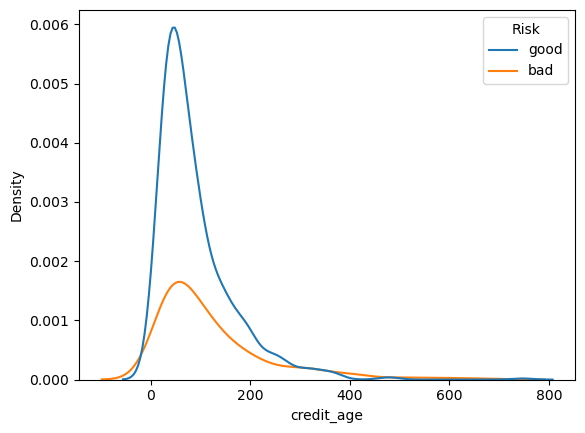

In [24]:
sns.kdeplot(data=df,x='credit_age',hue='Risk')

In [25]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [26]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'Housing', 'Purpose'], drop_first=True)

In [27]:
df_encoded['Saving accounts']=df_encoded['Saving accounts'].map({'none':0,'little':1,'moderate':2,'quite rich':3,'rich':4})
df_encoded['Checking account']=df_encoded['Checking account'].map({'none':0,'little':1,'moderate':2,'rich':3})
df_encoded['Risk'] = df_encoded['Risk'].map({'good': 0, 'bad': 1})

In [28]:
y=df_encoded['Risk']
x=df_encoded.drop(columns=['Risk'])
for col in x.columns:
    if x[col].isnull().sum() > 0:
        x[col] = x[col].fillna(x[col].median())

In [29]:
x.shape

(1000, 16)

In [30]:
y.shape

(1000,)

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(700, 16) (700,)
(300, 16) (300,)


In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
from sklearn.metrics import accuracy_score, classification_report

In [34]:
tree_gini_un = DecisionTreeClassifier(criterion='gini', max_depth=None, class_weight='balanced', random_state=42)
tree_gini_un.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [35]:
y_train_pred_gini = tree_gini_un.predict(X_train)
y_test_pred_gini = tree_gini_un.predict(X_test)

In [36]:
tree_entropy_un = DecisionTreeClassifier(criterion='entropy', max_depth=None, class_weight='balanced', random_state=42)
tree_entropy_un.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [37]:
y_train_pred_ent = tree_entropy_un.predict(X_train)
y_test_pred_ent = tree_entropy_un.predict(X_test)

In [38]:
print("=== VERIFYING GINI UNCONSTRAINED PERF ===")
print("=============================================")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_gini):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred_gini):.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred_gini))

=== VERIFYING GINI UNCONSTRAINED PERF ===
Train Accuracy: 1.0000
Test Accuracy:  0.6667

Test Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       210
           1       0.44      0.44      0.44        90

    accuracy                           0.67       300
   macro avg       0.60      0.60      0.60       300
weighted avg       0.67      0.67      0.67       300



In [39]:
print("=== VERIFYING ENTROPY UNCONSTRAINED PERF ===")
print("=============================================")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_ent):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred_ent):.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred_ent))

=== VERIFYING ENTROPY UNCONSTRAINED PERF ===
Train Accuracy: 1.0000
Test Accuracy:  0.6800

Test Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       210
           1       0.47      0.47      0.47        90

    accuracy                           0.68       300
   macro avg       0.62      0.62      0.62       300
weighted avg       0.68      0.68      0.68       300



In [40]:
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth':[3,4,5,6,7,8,9,None], 'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],'criterion':['gini','entropy']}
grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=42),param_grid, scoring='roc_auc', cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)

{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 12} 0.7048833819241982


In [41]:
tree_gini = DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_leaf=12,class_weight='balanced',random_state=42)

In [42]:
tree_entropy = DecisionTreeClassifier(criterion='entropy',max_depth=7,min_samples_leaf=12,class_weight='balanced',random_state=42)

In [43]:
tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,12
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [44]:
y_train_pred_gini=tree_gini.predict(X_train)
y_test_pred_gini = tree_gini.predict(X_test)

In [45]:
print("=== GINI CONSTRAINED TREE (depth=7,min_samples_leaf=12")
print("=============================================")
print(f"Training Set Accuracy:  {accuracy_score(y_train, y_train_pred_gini):.4f}")
print(f"Testing Set Accuracy:  {accuracy_score(y_test, y_test_pred_gini):.4f}")
print("\nTesting Set Classification Report:")
print(classification_report(y_test, y_test_pred_gini))

=== GINI CONSTRAINED TREE (depth=7,min_samples_leaf=12
Training Set Accuracy:  0.7471
Testing Set Accuracy:  0.6833

Testing Set Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.70      0.75       210
           1       0.48      0.66      0.55        90

    accuracy                           0.68       300
   macro avg       0.65      0.68      0.65       300
weighted avg       0.72      0.68      0.69       300



In [46]:
y_train_pred_entropy = tree_entropy.predict(X_train)
y_test_pred_entropy = tree_entropy.predict(X_test)

In [47]:
print("=== ENTROPY CONSTRAINED TREE (depth=7,min_samples_leaf=12) ===")
print("=============================================")
print(f"Training Set Accuracy:  {accuracy_score(y_train, y_train_pred_entropy):.4f}")
print(f"Testing Set Accuracy:  {accuracy_score(y_test, y_test_pred_entropy):.4f}")
print("\nTesting Set Classification Report:")
print(classification_report(y_test, y_test_pred_entropy))

=== ENTROPY CONSTRAINED TREE (depth=7,min_samples_leaf=12) ===
Training Set Accuracy:  0.7114
Testing Set Accuracy:  0.6167

Testing Set Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.56      0.67       210
           1       0.42      0.74      0.54        90

    accuracy                           0.62       300
   macro avg       0.63      0.65      0.61       300
weighted avg       0.71      0.62      0.63       300



In [48]:
from sklearn.metrics import roc_auc_score, confusion_matrix

In [49]:
def credit_cost(y_true,y_pred,fn_cost=5,fp_cost=1):
    tn,fp,fn,tp= confusion_matrix(y_true,y_pred).ravel()
    return fn*fn_cost+fp*fp_cost

In [50]:
y_proba_gini = tree_gini.predict_proba(X_test)[:, 1]
y_proba_entropy = tree_entropy.predict_proba(X_test)[:, 1]

In [51]:
print("=== GINI (default threshold) ===")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gini))
print("Cost:", credit_cost(y_test, y_test_pred_gini))

=== GINI (default threshold) ===
ROC-AUC: 0.7199735449735449
Cost: 219


In [52]:
print("\n=== ENTROPY (default threshold) ===")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_entropy))
print("Cost:", credit_cost(y_test, y_test_pred_entropy))


=== ENTROPY (default threshold) ===
ROC-AUC: 0.7019841269841269
Cost: 207


In [53]:
from sklearn.metrics import precision_recall_curve

In [54]:
def best_threshold_and_cost(y_true, y_proba, fn_cost=5, fp_cost=1):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    costs = [credit_cost(y_true, (y_proba >= t).astype(int), fn_cost, fp_cost) for t in thresholds]
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx]

In [55]:
best_t_gini, best_cost_gini = best_threshold_and_cost(y_test, y_proba_gini)
print("GINI:    best_threshold =", round(best_t_gini, 3), " min_cost =", best_cost_gini)

GINI:    best_threshold = 0.318  min_cost = 183


In [56]:
best_t_entropy, best_cost_entropy = best_threshold_and_cost(y_test, y_proba_entropy)
print("ENTROPY: best_threshold =", round(best_t_entropy, 3), " min_cost =", best_cost_entropy)

ENTROPY: best_threshold = 0.318  min_cost = 190


In [57]:
from sklearn.model_selection import validation_curve

In [58]:
depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, None]
train_scores, val_scores = validation_curve(DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42),x, y, param_name='max_depth', param_range=depths, cv=5, scoring='roc_auc')

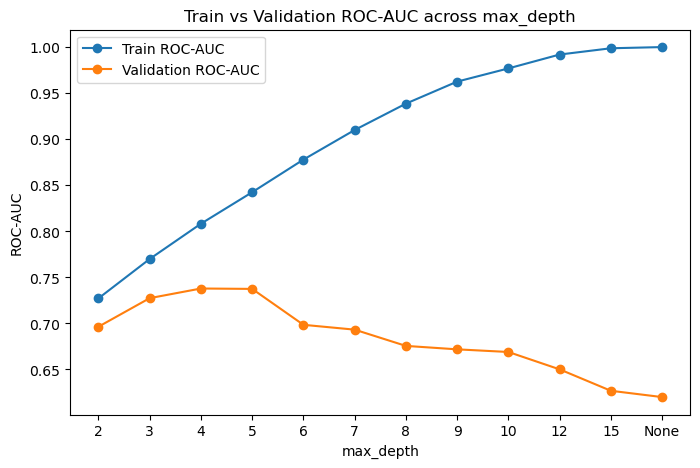

In [59]:
plt.figure(figsize=(8,5))
plt.plot(range(len(depths)), train_scores.mean(axis=1), marker='o', label='Train ROC-AUC')
plt.plot(range(len(depths)), val_scores.mean(axis=1), marker='o', label='Validation ROC-AUC')
plt.xticks(range(len(depths)), [str(d) for d in depths])
plt.xlabel('max_depth'); plt.ylabel('ROC-AUC')
plt.title('Train vs Validation ROC-AUC across max_depth')
plt.legend()
plt.show()

In [60]:
leaf_range = list(range(1, 31))
train_scores_leaf, val_scores_leaf = validation_curve(DecisionTreeClassifier(criterion='gini', max_depth=None, class_weight='balanced', random_state=42),x, y, param_name='min_samples_leaf', param_range=leaf_range, cv=5, scoring='roc_auc')

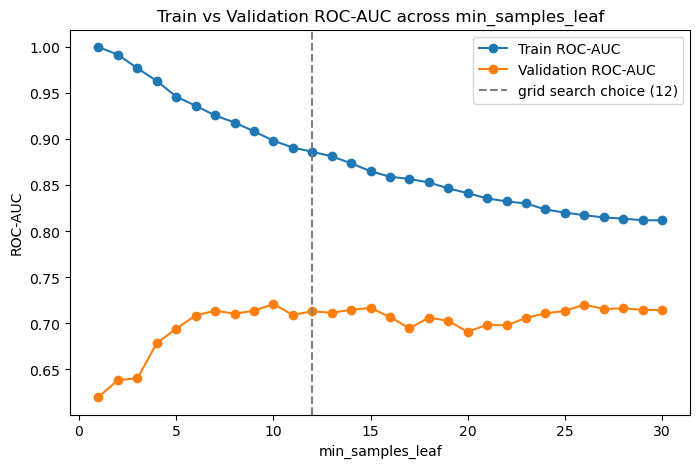

In [61]:

plt.figure(figsize=(8,5))
plt.plot(leaf_range, train_scores_leaf.mean(axis=1), marker='o', label='Train ROC-AUC')
plt.plot(leaf_range, val_scores_leaf.mean(axis=1), marker='o', label='Validation ROC-AUC')
plt.xlabel('min_samples_leaf'); plt.ylabel('ROC-AUC')
plt.title('Train vs Validation ROC-AUC across min_samples_leaf')
plt.legend()
plt.axvline(12, color='gray', linestyle='--', label='grid search choice (12)')
plt.legend()
plt.show()

In [62]:
candidates = [{'max_depth': 4, 'min_samples_leaf': 10},{'max_depth': 5, 'min_samples_leaf': 10},{'max_depth': 5, 'min_samples_leaf': 15},{'max_depth': 7, 'min_samples_leaf': 12}]

In [63]:
for params in candidates:
    t = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42, **params)
    t.fit(X_train, y_train)
    proba = t.predict_proba(X_test)[:, 1]
    best_t, best_c = best_threshold_and_cost(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    print(params, "-> ROC-AUC:", round(auc, 4), " best_threshold:", round(best_t, 3), " min_cost:", best_c)

{'max_depth': 4, 'min_samples_leaf': 10} -> ROC-AUC: 0.7075  best_threshold: 0.341  min_cost: 176
{'max_depth': 5, 'min_samples_leaf': 10} -> ROC-AUC: 0.7048  best_threshold: 0.538  min_cost: 186
{'max_depth': 5, 'min_samples_leaf': 15} -> ROC-AUC: 0.7098  best_threshold: 0.127  min_cost: 200
{'max_depth': 7, 'min_samples_leaf': 12} -> ROC-AUC: 0.72  best_threshold: 0.318  min_cost: 183


In [64]:
tree_full = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42)
tree_full.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [65]:
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1] 

In [66]:
costs_by_alpha, aucs_by_alpha = [], []
for alpha in ccp_alphas:
    t = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42, ccp_alpha=alpha)
    t.fit(X_train, y_train)
    proba = t.predict_proba(X_test)[:, 1]
    _, best_c = best_threshold_and_cost(y_test, proba)
    costs_by_alpha.append(best_c)
    aucs_by_alpha.append(roc_auc_score(y_test, proba))

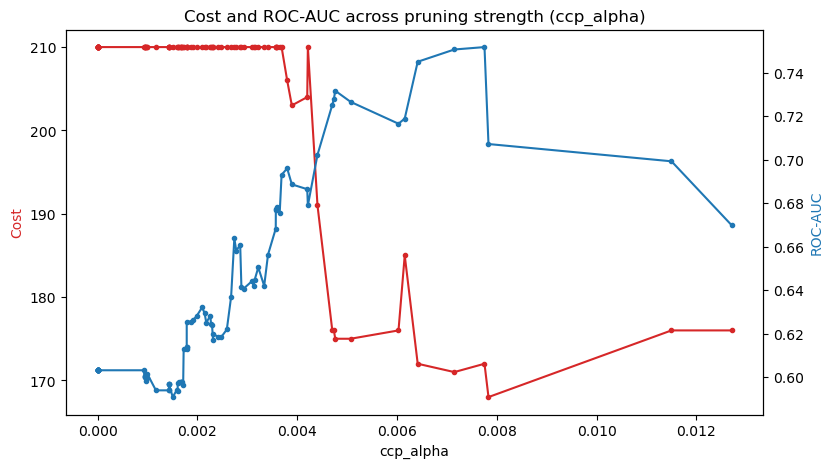

In [67]:
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(ccp_alphas, costs_by_alpha, color='tab:red', marker='.', label='Best cost')
ax1.set_xlabel('ccp_alpha'); ax1.set_ylabel('Cost', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(ccp_alphas, aucs_by_alpha, color='tab:blue', marker='.', label='ROC-AUC')
ax2.set_ylabel('ROC-AUC', color='tab:blue')
plt.title('Cost and ROC-AUC across pruning strength (ccp_alpha)')
plt.show()

In [68]:
best_idx = np.argmin(costs_by_alpha)
print("Best ccp_alpha:", ccp_alphas[best_idx], " Cost:", costs_by_alpha[best_idx], " ROC-AUC:", aucs_by_alpha[best_idx])

Best ccp_alpha: 0.007832497591044818  Cost: 168  ROC-AUC: 0.7071957671957672


In [69]:
best_alpha = ccp_alphas[np.argmin(costs_by_alpha)]
final_tree = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42, ccp_alpha=best_alpha)
final_tree.fit(X_train, y_train)
y_proba_final = final_tree.predict_proba(X_test)[:, 1]
final_threshold, final_cost = best_threshold_and_cost(y_test, y_proba_final)
final_preds = (y_proba_final >= final_threshold).astype(int)

In [77]:
print("Final tree — ccp_alpha:", best_alpha)
print("Depth:", final_tree.get_depth(), " Leaves:", final_tree.get_n_leaves())
print("ROC AUC: ",roc_auc_score(y_test,y_proba_final))
print("Threshold:", round(final_threshold, 3), " Cost:", final_cost)
print("\nClassification report:")
print(classification_report(y_test, final_preds))

Final tree — ccp_alpha: 0.007832497591044818
Depth: 2  Leaves: 4
ROC AUC:  0.7071957671957672
Threshold: 0.392  Cost: 168

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.49      0.63       210
           1       0.42      0.87      0.57        90

    accuracy                           0.60       300
   macro avg       0.66      0.68      0.60       300
weighted avg       0.75      0.60      0.61       300



In [71]:
from sklearn.tree import plot_tree

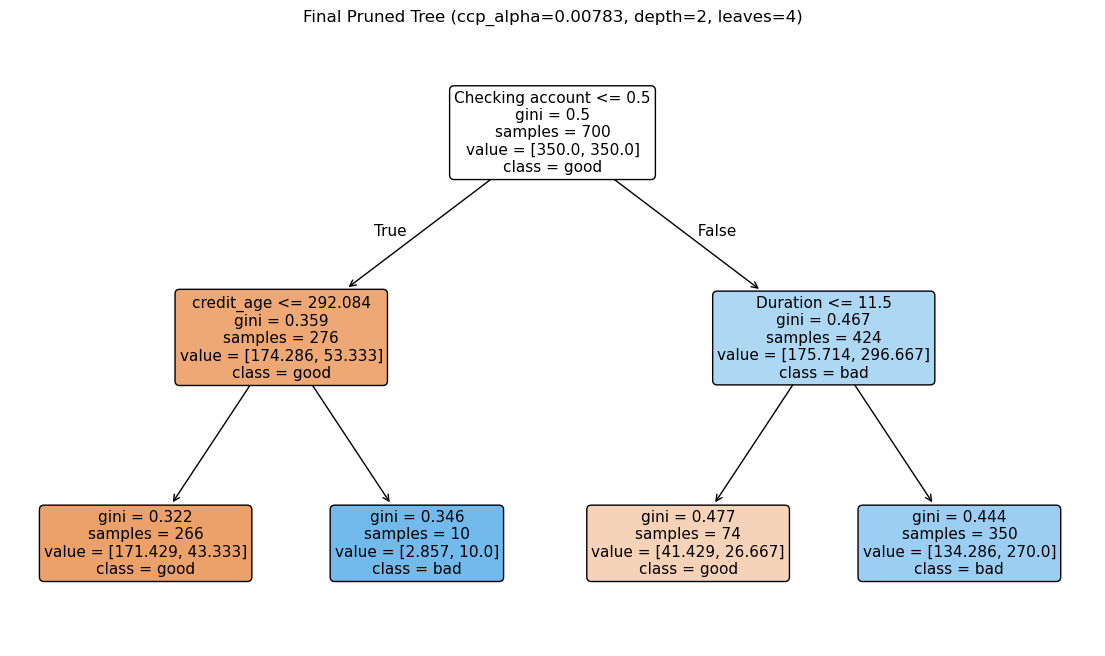

In [72]:
plt.figure(figsize=(14, 8))
plot_tree(final_tree, feature_names=x.columns, class_names=['good', 'bad'],filled=True, rounded=True, fontsize=11)
plt.title(f"Final Pruned Tree (ccp_alpha={best_alpha:.5f}, depth=2, leaves=4)")
plt.show()

In [73]:
importances = pd.Series(final_tree.feature_importances_, index=x.columns).sort_values(ascending=False)
print(importances[importances > 0])

Checking account    0.737569
Duration            0.137756
credit_age          0.124675
dtype: float64


In [74]:
stability_runs = []
for seed in range(20):
    t = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=seed, ccp_alpha=best_alpha)
    t.fit(X_train, y_train)
    stability_runs.append(pd.Series(t.feature_importances_, index=x.columns))

stability_df = pd.DataFrame(stability_runs)
stability_summary = pd.DataFrame({'mean': stability_df.mean(), 'std': stability_df.std()}).sort_values('mean', ascending=False)
print(stability_summary[stability_summary['mean'] > 0])

                      mean       std
Checking account  0.644063  0.095935
Duration          0.120292  0.017918
credit_age        0.108870  0.016216
Credit amount     0.065319  0.067016
Saving accounts   0.033431  0.034300
credit_per_month  0.028025  0.028753
